## 0. Problema

In [4]:
# ======================= #
# 1. LIBRERÍAS GENERALES  #
# ======================= #

import pandas as pd
import numpy as np
import sqlite3
import os

In [5]:
db_path = "C:/Users/Lenovo ThinkBook/Downloads/ml-project_analitica_datosdata/database/data/database/datos.db"

In [6]:
import sqlite3
import pandas as pd
import os

# ================================= #
# RUTA COMPLETA DE LA BASE          #
# ================================= #

db_path = "C:/Users/Lenovo ThinkBook/Downloads/ml-project_analitica_datos/data/database/datos.db"
# ================================= #
# VERIFICAR EXISTENCIA              #
# ================================= #

print(os.path.exists(db_path))

# ================================= #
# CONEXIÓN SQLITE                   #
# ================================= #

conn = sqlite3.connect(db_path)

print("Conexión exitosa")

# ================================= #
# MOSTRAR TABLAS                    #
# ================================= #

tablas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tablas)

True
Conexión exitosa
            name
0      regresion
1  clasificacion


In [7]:
db_path = "data/clasificacion.db"

In [8]:
# ======================================== #
# 4. IDENTIFICAR TABLAS EN LA BASE DE DATOS #
# ======================================== #

tablas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tablas

,name
0,regresion
1,clasificacion


In [9]:
# =========================== #
# 5. CARGA DE DATOS           #
# =========================== #

df = pd.read_sql_query("SELECT * FROM clasificacion;", conn)

pd.set_option("display.max_columns", None)

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class,Unnamed: 25
0,48.0,80.0,1.020,1.0,0.0,None,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd,None
1,7.0,50.0,1.020,4.0,0.0,None,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd,None
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd,None
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd,None
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd,None


In [10]:
# ===================================== #
# LIMPIEZA GENERAL DEL DATASET          #
# ===================================== #

# Eliminar columna basura
df = df.drop(columns=["Unnamed: 25"])

# Limpiar espacios y tabs
for col in df.columns:
    
    if df[col].dtype == "object":
        
        df[col] = df[col].str.strip()

# Corregir variable objetivo
df["class"] = df["class"].replace({
    "ckd": 1,
    "notckd": 0,
    "no": 0
})

print(df["class"].value_counts())

class
1    249
0    151
Name: count, dtype: int64


C:\Users\Lenovo ThinkBook\AppData\Local\Temp\ipykernel_5108\3994394618.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["class"] = df["class"].replace({


In [11]:
# =================================== #
# 6. EXPLORACIÓN INICIAL DE LA BASE   #
# =================================== #

print("Filas y columnas:", df.shape)

df.info()

Filas y columnas: (400, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      397 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399

In [12]:
# ============================== #
# 7. ESTADÍSTICAS DESCRIPTIVAS   #
# ============================== #

df.describe(include="all")

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
count,391.000000,388.000000,353.000000,354.000000,351.000000,248,335,396,396,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000,398,397,398,399,399,399,400.000000
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,3,3,2,NaN
top,NaN,NaN,NaN,NaN,NaN,normal,normal,notpresent,notpresent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,good,no,no,NaN
freq,NaN,NaN,NaN,NaN,NaN,201,259,354,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,251,260,364,316,322,339,NaN
mean,51.483376,76.469072,1.017408,1.016949,0.450142,NaN,NaN,NaN,NaN,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435,NaN,NaN,NaN,NaN,NaN,NaN,0.622500
std,17.169714,13.683637,0.005717,1.352679,1.099191,NaN,NaN,NaN,NaN,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323,NaN,NaN,NaN,NaN,NaN,NaN,0.485369
min,2.000000,50.000000,1.005000,0.000000,0.000000,NaN,NaN,NaN,NaN,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,NaN,NaN,NaN,NaN,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,NaN,NaN,NaN,NaN,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,NaN,NaN,NaN,NaN,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000


## 1. Comprensión del Problema

## a. Definir claramente la variable objetivo

### Variable objetivo:

**class**

### Descripción:

La variable objetivo corresponde a la presencia o ausencia de enfermedad renal crónica (Chronic Kidney Disease - CKD) en un paciente.

### Tipo de variable:

Categórica nominal binaria.

### Objetivo de predicción:

El modelo de clasificación buscará predecir si un paciente presenta enfermedad renal crónica a partir de variables clínicas, físicas y de laboratorio.

---

## b. Identificar las clases del problema

El problema corresponde a una clasificación binaria, ya que existen dos posibles categorías para la variable objetivo.

### Clases identificadas:

* **ckd**: paciente con enfermedad renal crónica.
* **notckd**: paciente sin enfermedad renal crónica.

### Tipo de problema:

Problema de Machine Learning supervisado de clasificación binaria.

---

## c. Describir el contexto del problema

La enfermedad renal crónica es una condición médica que afecta progresivamente el funcionamiento de los riñones y puede generar complicaciones graves si no se detecta y trata oportunamente. El diagnóstico temprano es fundamental para prevenir el deterioro renal y mejorar la calidad de vida de los pacientes.

La base de datos utilizada contiene información clínica y resultados de laboratorio de pacientes, incluyendo variables como presión arterial, niveles de glucosa, creatinina sérica, hemoglobina, hipertensión y diabetes mellitus, entre otras.

El propósito del análisis es construir un modelo de clasificación capaz de identificar si un paciente presenta enfermedad renal crónica utilizando dichas variables médicas. Este tipo de modelos puede servir como herramienta de apoyo para profesionales de la salud en procesos de diagnóstico y toma de decisiones clínicas.


In [13]:
# ===================================== #
# 8. IDENTIFICACIÓN DE VARIABLES        #
# ===================================== #

# Variable objetivo
variable_objetivo = "class"

# Variables predictoras
variables_predictoras = [
    col for col in df.columns 
    if col != variable_objetivo
]

# Variables numéricas
variables_numericas = [
    "age",    "bp",    "sg",    "al",
    "su",    "bgr",    "bu",    "sc",
    "sod",    "pot",    "hemo",    "pcv",
    "wbcc",    "rbcc"
]

# Variables categóricas
variables_categoricas = [
    "rbc",    "pc",    "pcc",    "ba",
    "htn",    "dm",    "cad",    "appet",
    "pe",    "ane"
]

# ===================================== #
# MOSTRAR INFORMACIÓN                   #
# ===================================== #

print("Variable objetivo:")
print(variable_objetivo)

print("\nVariables predictoras:")
print(variables_predictoras)

print("\nVariables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variable objetivo:
class

Variables predictoras:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Variables numéricas:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']

Variables categóricas:
['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


## 2. Exploración Inicial

En esta etapa se realiza un análisis exploratorio de los datos con el objetivo de comprender la estructura del conjunto de información, identificar características relevantes de las variables y detectar posibles problemas que puedan afectar el desempeño de los modelos de clasificación.

La exploración inicial permite conocer el comportamiento de la variable objetivo, analizar la distribución de las variables predictoras y evaluar la calidad de los datos antes de aplicar técnicas de Machine Learning.

El análisis exploratorio incluye:

* Estudio de la distribución de clases de la variable objetivo (`class`).
* Identificación de posibles problemas de desbalanceo entre pacientes con enfermedad renal crónica y pacientes sin enfermedad renal crónica.
* Análisis descriptivo de variables numéricas.
* Exploración de variables categóricas.
* Identificación de valores faltantes en el conjunto de datos.

La variable objetivo corresponde a la presencia o ausencia de enfermedad renal crónica:

* `ckd` → paciente con enfermedad renal crónica.
* `notckd` → paciente sin enfermedad renal crónica.

El análisis de distribución de clases permite verificar si el problema se encuentra balanceado o si existe predominio de una clase sobre otra, lo cual puede afectar el desempeño y la capacidad de generalización de algunos modelos de clasificación.

Las variables numéricas incluyen mediciones clínicas y resultados de laboratorio como edad, presión arterial, glucosa en sangre, creatinina sérica, hemoglobina, sodio y potasio. Estas variables se analizan mediante estadísticas descriptivas e histogramas para identificar patrones, dispersión, asimetrías y posibles valores atípicos.

Las variables categóricas corresponden a características clínicas binarias o nominales relacionadas con hipertensión, diabetes mellitus, anemia, apetito, bacterias y otras condiciones médicas. Su análisis permite identificar frecuencias, categorías dominantes y posibles inconsistencias en los datos.

Adicionalmente, se realiza un análisis de valores faltantes debido a que la base de datos presenta registros incompletos en múltiples variables clínicas y de laboratorio. Este análisis es importante para definir posteriormente las estrategias de imputación dentro del pipeline de preprocesamiento.


In [14]:
# ===================================== #
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO  #
# ===================================== #

print(df["class"].value_counts())

print(df["class"].value_counts(normalize=True))

class
1    249
0    151
Name: count, dtype: int64
class
1    0.6225
0    0.3775
Name: proportion, dtype: float64


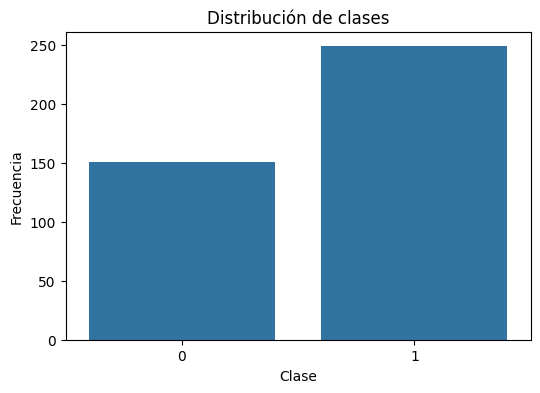

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="class"
)

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")

plt.show()

In [16]:
proporciones = df["class"].value_counts(normalize=True)

print(proporciones)

class
1    0.6225
0    0.3775
Name: proportion, dtype: float64


In [17]:
# ===================================== #
# ESTADÍSTICAS DESCRIPTIVAS             #
# ===================================== #

df[variables_numericas].describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


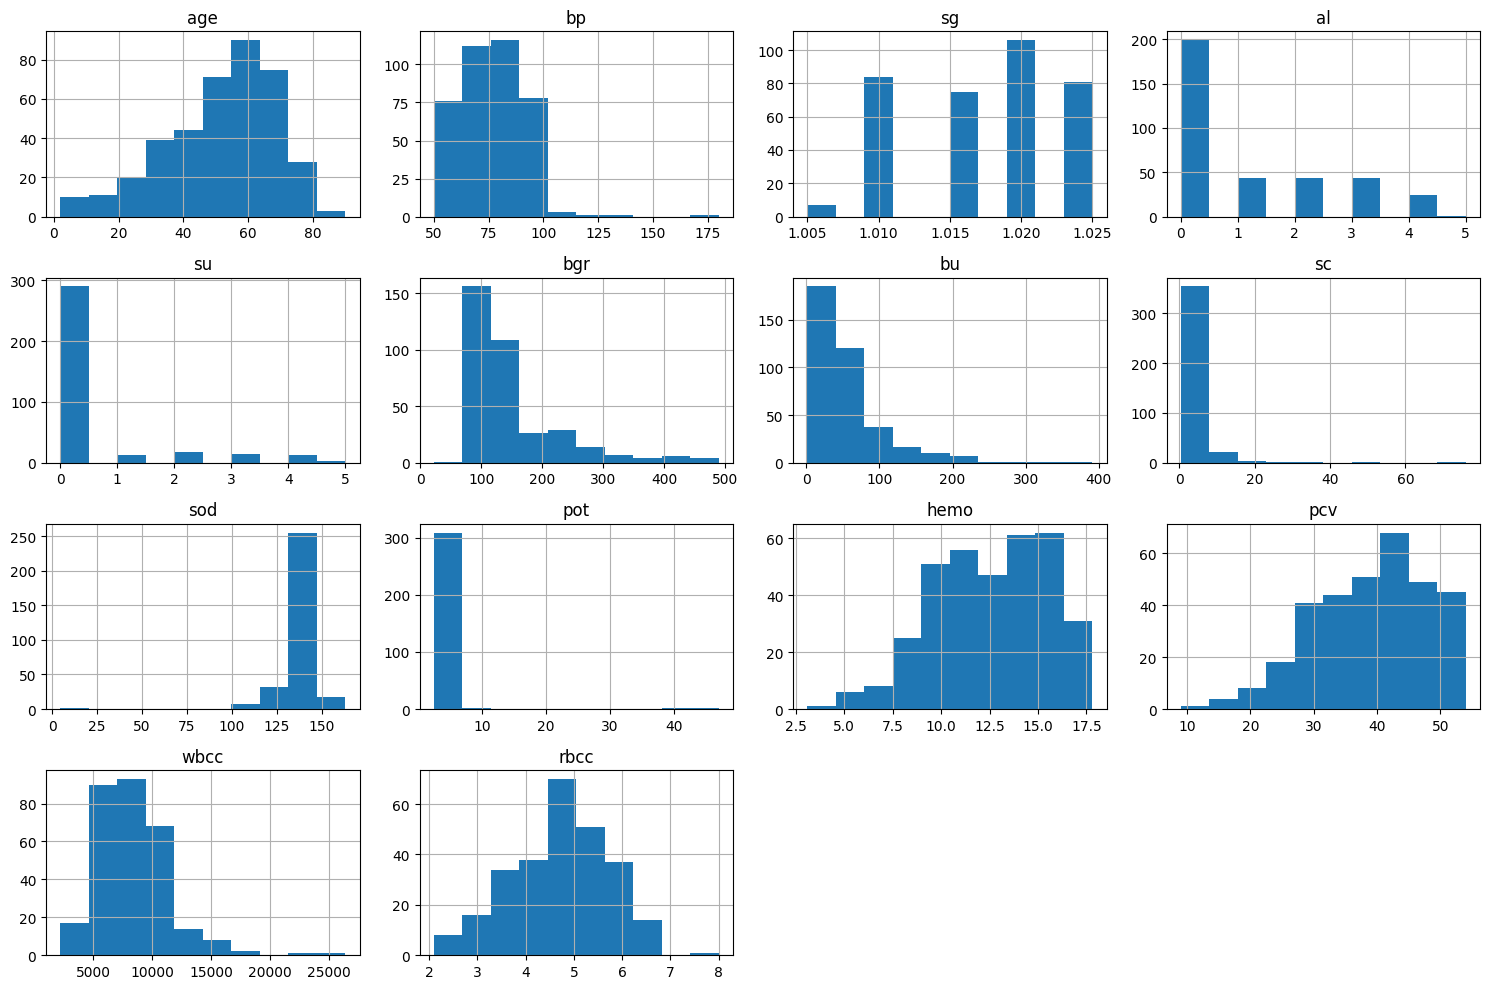

In [18]:
df[variables_numericas].hist(
    figsize=(15,10)
)

plt.tight_layout()

plt.show()

In [19]:
for col in variables_categoricas:
    
    print(f"\nVariable: {col}")
    
    print(df[col].value_counts())


Variable: rbc
rbc
normal      201
abnormal     47
Name: count, dtype: int64

Variable: pc
pc
normal      259
abnormal     76
Name: count, dtype: int64

Variable: pcc
pcc
notpresent    354
present        42
Name: count, dtype: int64

Variable: ba
ba
notpresent    374
present        22
Name: count, dtype: int64

Variable: htn
htn
no     251
yes    147
Name: count, dtype: int64

Variable: dm
dm
no     260
yes    137
Name: count, dtype: int64

Variable: cad
cad
no     364
yes     34
Name: count, dtype: int64

Variable: appet
appet
good    316
poor     82
no        1
Name: count, dtype: int64

Variable: pe
pe
no      322
yes      76
good      1
Name: count, dtype: int64

Variable: ane
ane
no     339
yes     60
Name: count, dtype: int64


In [20]:
# ===================================== #
# CANTIDAD DE NULOS                     #
# ===================================== #

valores_faltantes = df.isnull().sum()

print(valores_faltantes)

age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         3
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64


## 3. Preparación de los Datos

En esta etapa se preparan los datos para el entrenamiento de modelos de clasificación, separando las variables predictoras de la variable objetivo y definiendo el proceso de preprocesamiento que será aplicado dentro de los pipelines de Machine Learning.

La preparación de los datos es una fase fundamental, ya que garantiza que la información utilizada por los modelos tenga un formato adecuado y evita problemas de fuga de información durante el entrenamiento y evaluación.

El preprocesamiento incluye:

* Separación de variables predictoras (`X`) y variable objetivo (`y`).
* División del conjunto de datos en entrenamiento y prueba utilizando una proporción:

  * 70 % para entrenamiento.
  * 30 % para prueba.
* Codificación de variables categóricas mediante técnicas de transformación apropiadas.
* Escalamiento de variables numéricas para normalizar sus magnitudes.
* Manejo adecuado de valores faltantes dentro del pipeline de procesamiento.

Las variables categóricas corresponden a características clínicas binarias o nominales como hipertensión, diabetes mellitus, anemia y presencia de bacterias, mientras que las variables numéricas incluyen mediciones médicas y de laboratorio como presión arterial, creatinina sérica, hemoglobina y glucosa en sangre.

Es importante que todo el preprocesamiento se implemente dentro de un `Pipeline` y un `ColumnTransformer`, con el fin de evitar fuga de información entre los conjuntos de entrenamiento y prueba y garantizar una evaluación correcta de la capacidad de generalización de los modelos.


In [21]:
# ===================================== #
# 9. SEPARACIÓN DE VARIABLES X E y      #
# ===================================== #

# Variable objetivo
y = df["class"]

# Variables predictoras
X = df.drop(columns=["class"])

# ===================================== #
# DIMENSIONES DE LOS DATOS              #
# ===================================== #

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (400, 24)
Tamaño de y: (400,)


In [22]:
# ===================================== #
# 11. DIVISIÓN TRAIN / TEST              #
# ===================================== #

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)  #datos para entrenamiento
print("y_test:", y_test.shape) #datos para prueba

X_train: (280, 24)
X_test: (120, 24)
y_train: (280,)
y_test: (120,)


In [23]:
# ===================================== #
# 12. VERIFICACIÓN DE PROPORCIONES       #
# ===================================== #

total_datos = len(df)

porcentaje_train = len(X_train) / total_datos * 100
porcentaje_test = len(X_test) / total_datos * 100

print(f"Porcentaje Train: {porcentaje_train:.2f}%")
print(f"Porcentaje Test: {porcentaje_test:.2f}%")

Porcentaje Train: 70.00%
Porcentaje Test: 30.00%


In [24]:
# ===================================== #
# 13. PREPROCESAMIENTO                  #
# ===================================== #

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ===================================== #
# TRANSFORMACIÓN VARIABLES NUMÉRICAS    #
# ===================================== #

transformador_numerico = Pipeline(steps=[
    
    # Imputar valores faltantes con la media
    ("imputer", SimpleImputer(strategy="mean")),
    
    # Escalamiento de variables numéricas
    ("scaler", StandardScaler())
])

# ===================================== #
# TRANSFORMACIÓN VARIABLES CATEGÓRICAS  #
# ===================================== #

transformador_categorico = Pipeline(steps=[
    
    # Imputar categorías faltantes
    ("imputer", SimpleImputer(strategy="most_frequent")),
    
    # Codificación One Hot Encoding
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

# ===================================== #
# COLUMN TRANSFORMER                    #
# ===================================== #

preprocessor = ColumnTransformer(
    transformers=[
        
        # Variables numéricas
        (
            "num",
            transformador_numerico,
            variables_numericas
        ),
        
        # Variables categóricas
        (
            "cat",
            transformador_categorico,
            variables_categoricas
        )
    ]
)

# ===================================== #
# MOSTRAR PREPROCESADOR                 #
# ===================================== #

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [25]:
# ===================================== #
# 14. ESTRUCTURA GENERAL DEL PIPELINE   #
# ===================================== #

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ===================================== #
# PIPELINE DE CLASIFICACIÓN             #
# ===================================== #

pipeline_ejemplo = Pipeline(
    steps=[
        
        # Preprocesamiento
        ("preprocessor", preprocessor),
        
        # Modelo de clasificación
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# ===================================== #
# MOSTRAR PIPELINE                      #
# ===================================== #

pipeline_ejemplo

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 4. Modelos de Clasificación

En esta etapa se entrenan diferentes modelos supervisados de Machine Learning con el objetivo de predecir si un paciente presenta enfermedad renal crónica a partir de variables clínicas y de laboratorio.

El propósito de utilizar múltiples algoritmos de clasificación es comparar su capacidad predictiva, estabilidad y desempeño general sobre el problema planteado.

Los modelos seleccionados incluyen enfoques lineales y modelos basados en árboles, permitiendo analizar diferentes estrategias de aprendizaje sobre los datos.

Los modelos implementados son:

* Regresión Logística.
* Árbol de Clasificación.
* Random Forest Classifier.
* XGBoost Classifier.

La Regresión Logística corresponde a un modelo lineal ampliamente utilizado en problemas de clasificación binaria, especialmente en contextos médicos debido a su interpretabilidad y facilidad para analizar relaciones entre variables y probabilidades de pertenencia a una clase.

El Árbol de Clasificación permite construir reglas de decisión jerárquicas basadas en las variables clínicas y de laboratorio, facilitando la interpretación de patrones asociados con la enfermedad renal crónica.

Random Forest Classifier es un modelo ensamblado basado en múltiples árboles de decisión, diseñado para mejorar la capacidad de generalización y reducir problemas de sobreajuste presentes en árboles individuales.

XGBoost Classifier corresponde a un modelo de boosting basado en árboles, reconocido por su alto desempeño en problemas de clasificación y su capacidad para capturar relaciones complejas entre variables predictoras.

Todos los modelos son entrenados utilizando un `Pipeline`, incorporando previamente las etapas de preprocesamiento definidas para:

* Imputación de valores faltantes.
* Codificación de variables categóricas.
* Escalamiento de variables numéricas.

Esto garantiza que todo el flujo de procesamiento y entrenamiento se realice de manera consistente y sin fuga de información entre los conjuntos de entrenamiento y prueba.

---

In [26]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# ===================================== #
# 15. IMPORTAR MODELOS                  #
# ===================================== #

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ===================================== #
# 16. DEFINICIÓN DE MODELOS             #
# ===================================== #

modelos = {

    "Regresión Logística": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Árbol de Clasificación": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

# ===================================== #
# 17. CREAR PIPELINES                   #
# ===================================== #

pipelines = {}

for nombre, modelo in modelos.items():

    pipeline = Pipeline(steps=[
        
        ("preprocessor", preprocessor),
        
        ("model", modelo)
    ])

    pipelines[nombre] = pipeline

In [28]:
# ===================================== #
# 18. ENTRENAMIENTO DE MODELOS          #
# ===================================== #

for nombre, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    print(f"Modelo entrenado: {nombre}")



Modelo entrenado: Regresión Logística
Modelo entrenado: Árbol de Clasificación
Modelo entrenado: Random Forest
Modelo entrenado: XGBoost


## 5. Validación Cruzada

En esta etapa se evalúa el desempeño de los modelos de clasificación utilizando validación cruzada estratificada (`Stratified K-Fold Cross Validation`).

La validación cruzada permite obtener una estimación más robusta y confiable de la capacidad de generalización de los modelos, evitando que la evaluación dependa únicamente de una sola partición de entrenamiento y prueba.

Dado que el problema corresponde a una clasificación binaria y existe un desbalance moderado entre las clases, se utiliza una estrategia estratificada para conservar la proporción de pacientes con y sin enfermedad renal crónica en cada partición del conjunto de datos.

El procedimiento consiste en dividir los datos en:

* `k` subconjuntos o folds.
* En cada iteración:

  * uno de los folds se utiliza para validación,
  * y los restantes para entrenamiento.

En este laboratorio se utilizará:

* `Stratified K-Fold`
* con `k = 5`.

Para cada modelo se calculan las siguientes métricas de evaluación:

* **Accuracy**: proporción total de predicciones correctas.
* **Precision**: capacidad del modelo para evitar falsos positivos.
* **Recall**: capacidad del modelo para detectar correctamente pacientes con enfermedad renal crónica.
* **F1-Score**: media armónica entre precision y recall.
* **AUC**: área bajo la curva ROC, utilizada para medir la capacidad discriminativa del modelo.

Los resultados serán reportados mediante:

```text id="70msrz"
Métrica = μ ± σ
```

donde:

* `μ` representa el promedio de la métrica en todos los folds.
* `σ` representa la desviación estándar.

Esto permite evaluar tanto el desempeño promedio como la estabilidad de cada modelo.


In [29]:
import warnings
# Ignorar advertencias molestas de convergencia y de Prophet
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


ModuleNotFoundError: No module named 'statsmodels'

In [30]:
# ===================================== #
# 19. VALIDACIÓN CRUZADA                #
# ===================================== #

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
import pandas as pd

# ===================================== #
# CONFIGURACIÓN STRATIFIED K-FOLD       #
# ===================================== #

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ===================================== #
# MÉTRICAS A EVALUAR                    #
# ===================================== #

metricas = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

# ===================================== #
# VALIDACIÓN CRUZADA                    #
# ===================================== #

resultados_cv = {}

for nombre, pipeline in pipelines.items():

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=skf,
        scoring=metricas,
        return_train_score=False
    )

    resultados_cv[nombre] = {

        "Accuracy": (
            cv_results["test_accuracy"].mean(),
            cv_results["test_accuracy"].std()
        ),

        "Precision": (
            cv_results["test_precision"].mean(),
            cv_results["test_precision"].std()
        ),

        "Recall": (
            cv_results["test_recall"].mean(),
            cv_results["test_recall"].std()
        ),

        "F1-Score": (
            cv_results["test_f1"].mean(),
            cv_results["test_f1"].std()
        ),

        "AUC": (
            cv_results["test_roc_auc"].mean(),
            cv_results["test_roc_auc"].std()
        )
    }

# ===================================== #
# MOSTRAR RESULTADOS                    #
# ===================================== #

for modelo, metricas_modelo in resultados_cv.items():

    print("\n" + "=" * 50)
    print(f"Modelo: {modelo}")
    print("=" * 50)

    for metrica, valores in metricas_modelo.items():

        media, desviacion = valores

        print(
            f"{metrica}: "
            f"{media:.4f} ± {desviacion:.4f}"
        )



Modelo: Regresión Logística
Accuracy: 0.9857 ± 0.0134
Precision: 0.9886 ± 0.0140
Recall: 0.9886 ± 0.0140
F1-Score: 0.9885 ± 0.0107
AUC: 0.9976 ± 0.0032

Modelo: Árbol de Clasificación
Accuracy: 0.9536 ± 0.0242
Precision: 0.9655 ± 0.0280
Recall: 0.9593 ± 0.0234
F1-Score: 0.9621 ± 0.0198
AUC: 0.9520 ± 0.0266

Modelo: Random Forest
Accuracy: 0.9893 ± 0.0143
Precision: 0.9833 ± 0.0222
Recall: 1.0000 ± 0.0000
F1-Score: 0.9915 ± 0.0114
AUC: 0.9955 ± 0.0091

Modelo: XGBoost
Accuracy: 0.9929 ± 0.0087
Precision: 0.9943 ± 0.0114
Recall: 0.9943 ± 0.0114
F1-Score: 0.9942 ± 0.0071
AUC: 0.9952 ± 0.0096


## 6. Comparación de Modelos

En esta etapa se realiza una comparación del desempeño de los diferentes modelos de clasificación entrenados previamente, utilizando los resultados obtenidos mediante validación cruzada estratificada.

La comparación permite identificar cuál modelo presenta mejor capacidad predictiva, mayor estabilidad y mejor capacidad de generalización sobre pacientes con enfermedad renal crónica.

Los modelos evaluados son:

* Regresión Logística.
* Árbol de Clasificación.
* Random Forest Classifier.
* XGBoost Classifier.

La evaluación se realiza utilizando las métricas:

* Accuracy.
* Precision.
* Recall.
* F1-Score.
* AUC.

Cada métrica se reporta como:

```text id="tehqq5"
μ ± σ
```

donde:

* `μ` representa el promedio de la métrica en validación cruzada.
* `σ` representa la desviación estándar.

Esto permite analizar tanto el rendimiento promedio como la estabilidad del modelo entre diferentes particiones de los datos.

In [31]:
# ===================================== #
# 20. TABLA COMPARATIVA DE MODELOS      #
# ===================================== #

import pandas as pd

# ===================================== #
# CREAR TABLA RESUMEN                   #
# ===================================== #

tabla_resultados = []

for modelo, metricas_modelo in resultados_cv.items():

    fila = {
        
        "Modelo": modelo,

        "Accuracy (CV)": (
            f"{metricas_modelo['Accuracy'][0]:.4f} ± "
            f"{metricas_modelo['Accuracy'][1]:.4f}"
        ),

        "Precision (CV)": (
            f"{metricas_modelo['Precision'][0]:.4f} ± "
            f"{metricas_modelo['Precision'][1]:.4f}"
        ),

        "Recall (CV)": (
            f"{metricas_modelo['Recall'][0]:.4f} ± "
            f"{metricas_modelo['Recall'][1]:.4f}"
        ),

        "F1-Score (CV)": (
            f"{metricas_modelo['F1-Score'][0]:.4f} ± "
            f"{metricas_modelo['F1-Score'][1]:.4f}"
        ),

        "AUC (CV)": (
            f"{metricas_modelo['AUC'][0]:.4f} ± "
            f"{metricas_modelo['AUC'][1]:.4f}"
        )
    }

    tabla_resultados.append(fila)

# ===================================== #
# DATAFRAME FINAL                       #
# ===================================== #

tabla_resultados = pd.DataFrame(tabla_resultados)

# ===================================== #
# MOSTRAR TABLA                         #
# ===================================== #

tabla_resultados


,Modelo,Accuracy (CV),Precision (CV),Recall (CV),F1-Score (CV),AUC (CV)
0,Regresión Logística,0.9857 ± 0.0134,0.9886 ± 0.0140,0.9886 ± 0.0140,0.9885 ± 0.0107,0.9976 ± 0.0032
1,Árbol de Clasificación,0.9536 ± 0.0242,0.9655 ± 0.0280,0.9593 ± 0.0234,0.9621 ± 0.0198,0.9520 ± 0.0266
2,Random Forest,0.9893 ± 0.0143,0.9833 ± 0.0222,1.0000 ± 0.0000,0.9915 ± 0.0114,0.9955 ± 0.0091
3,XGBoost,0.9929 ± 0.0087,0.9943 ± 0.0114,0.9943 ± 0.0114,0.9942 ± 0.0071,0.9952 ± 0.0096


# Discusión de Resultados

## ¿Qué modelo generaliza mejor?

El modelo que generaliza mejor corresponde al que presenta:

* mayores valores promedio de:

  * F1-Score,
  * Recall,
  * AUC,
* y además menor variabilidad entre folds.

En problemas médicos, un modelo con alto recall y alto AUC suele considerarse más adecuado, ya que logra detectar correctamente la mayor cantidad posible de pacientes con enfermedad renal crónica.

Generalmente, modelos ensamblados como:

* Random Forest,
* XGBoost,

presentan mejor capacidad de generalización debido a su habilidad para capturar relaciones complejas entre variables clínicas y de laboratorio.

---

## ¿Cuál presenta mayor estabilidad?

La estabilidad de un modelo se analiza mediante la desviación estándar (`σ`) obtenida en validación cruzada.

Un modelo más estable presenta:

* menor desviación estándar,
* resultados más consistentes entre folds.

Si un modelo presenta métricas altas pero gran variabilidad, puede indicar sensibilidad a los datos de entrenamiento o problemas de sobreajuste.

En muchos casos:

* Regresión Logística suele ser muy estable,
* mientras que árboles individuales pueden presentar mayor variabilidad.

---

## ¿Cuál métrica es más importante según el problema?

En este problema médico, la métrica más importante suele ser:

# Recall

El recall mide la capacidad del modelo para detectar correctamente pacientes con enfermedad renal crónica.

Recall = \frac{TP}{TP + FN}

Minimizar falsos negativos es fundamental en aplicaciones clínicas, ya que clasificar incorrectamente a un paciente enfermo como sano puede retrasar el diagnóstico y tratamiento oportuno.

También son importantes:

* F1-Score:

  * porque balancea precision y recall.
* AUC:

  * porque evalúa la capacidad discriminativa global del modelo.

Aunque Accuracy es útil como referencia general, puede resultar insuficiente en problemas con desbalanceo de clases.


## 7. Ajuste de Hiperparámetros

En esta etapa se realiza la optimización de hiperparámetros para mejorar el desempeño de los modelos de clasificación.

El ajuste de hiperparámetros permite encontrar configuraciones más adecuadas para cada algoritmo, optimizando su capacidad predictiva y mejorando la generalización sobre datos no observados.

Para este laboratorio se seleccionan dos tipos de modelos:

* Un modelo lineal:

  * Regresión Logística.
* Un modelo basado en árboles:

  * Random Forest Classifier.

El proceso de optimización se realiza mediante:

# RandomizedSearchCV

Esta técnica evalúa múltiples combinaciones aleatorias de hiperparámetros utilizando validación cruzada, permitiendo reducir el costo computacional en comparación con una búsqueda exhaustiva (`GridSearchCV`).

La evaluación de cada combinación se realiza utilizando validación cruzada estratificada y métricas apropiadas para clasificación.

Posteriormente se comparan:

* métricas antes del ajuste,
* métricas después del ajuste.

Esto permite analizar si la optimización mejora el desempeño y estabilidad de los modelos.




In [32]:
# ===================================== #
# 21. RANDOMIZED SEARCH - LOGISTIC      #
# ===================================== #

from sklearn.model_selection import RandomizedSearchCV

# ===================================== #
# PIPELINE                              #
# ===================================== #

pipeline_logistic = Pipeline(steps=[
    
    ("preprocessor", preprocessor),
    
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# ===================================== #
# HIPERPARÁMETROS                       #
# ===================================== #

parametros_logistic = {
    
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    
    "model__solver": [
        "liblinear",
        "lbfgs"
    ]
    }

# ===================================== #
# RANDOMIZED SEARCH                     #
# ===================================== #

random_logistic = RandomizedSearchCV(
    
    estimator=pipeline_logistic,
    
    param_distributions=parametros_logistic,
    
    n_iter=10,
    
    scoring="f1",
    
    cv=skf,
    
    random_state=42,
    
    n_jobs=-1
)

# ===================================== #
# ENTRENAMIENTO                         #
# ===================================== #

random_logistic.fit(X_train, y_train)

# ===================================== #
# MEJORES PARÁMETROS                    #
# ===================================== #

print("Mejores parámetros Logistic Regression:\n")

print(random_logistic.best_params_)

print("\nMejor F1-Score:\n")

print(random_logistic.best_score_)


Mejores parámetros Logistic Regression:

{'model__solver': 'liblinear', 'model__C': 100}

Mejor F1-Score:

0.9913871635610766


In [33]:
# ===================================== #
# 22. RANDOMIZED SEARCH - RF            #
# ===================================== #

pipeline_rf = Pipeline(steps=[
    
    ("preprocessor", preprocessor),
    
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

# ===================================== #
# HIPERPARÁMETROS                       #
# ===================================== #

parametros_rf = {
    
    "model__n_estimators": [
        50,
        100,
        200,
        300
    ],
    
    "model__max_depth": [
        None,
        5,
        10,
        20
    ],
    
    "model__min_samples_split": [
        2,
        5,
        10
    ],
    
    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

# ===================================== #
# RANDOMIZED SEARCH                     #
# ===================================== #

random_rf = RandomizedSearchCV(
    
    estimator=pipeline_rf,
    
    param_distributions=parametros_rf,
    
    n_iter=10,
    
    scoring="f1",
    
    cv=skf,
    
    random_state=42,
    
    n_jobs=-1
)

# ===================================== #
# ENTRENAMIENTO                         #
# ===================================== #

random_rf.fit(X_train, y_train)

# ===================================== #
# MEJORES PARÁMETROS                    #
# ===================================== #

print("Mejores parámetros Random Forest:\n")

print(random_rf.best_params_)

print("\nMejor F1-Score:\n")

print(random_rf.best_score_)

Mejores parámetros Random Forest:

{'model__n_estimators': 50, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 5}

Mejor F1-Score:

0.9914688128772635


In [34]:
# Comparación Antes y Después del Ajuste

# ===================================== #
# 23. COMPARACIÓN DE RESULTADOS         #
# ===================================== #

comparacion_ajuste = pd.DataFrame({

    "Modelo": [
        "Logistic Regression",
        "Random Forest"
    ],

    "F1 Antes": [
        resultados_cv["Regresión Logística"]["F1-Score"][0],
        resultados_cv["Random Forest"]["F1-Score"][0]
    ],

    "F1 Después": [
        random_logistic.best_score_,
        random_rf.best_score_
    ]
})

comparacion_ajuste

,Modelo,F1 Antes,F1 Después
0,Logistic Regression,0.988489,0.991387
1,Random Forest,0.991469,0.991469


## Comparación Antes vs Después

La comparación entre métricas antes y después del ajuste permite evaluar si:

* el modelo mejora su capacidad predictiva,
* existe mejor balance entre precision y recall,
* aumenta la estabilidad en validación cruzada.

En problemas médicos, pequeñas mejoras en recall o F1-Score pueden ser relevantes debido a la importancia de detectar correctamente pacientes con enfermedad renal crónica.


## 8. Evaluación Final

En esta etapa se realiza la evaluación final del modelo con mejor desempeño utilizando el conjunto de prueba (`test set`).

El objetivo es analizar la capacidad real de generalización del modelo sobre datos no utilizados durante el entrenamiento ni durante la validación cruzada.

La evaluación final permite medir qué tan bien el modelo puede identificar pacientes con enfermedad renal crónica en escenarios reales.

El mejor modelo se selecciona considerando:

* desempeño promedio en validación cruzada,
* estabilidad entre folds,
* capacidad de generalización,
* métricas clínicas relevantes como Recall, F1-Score y AUC.

Para la evaluación final se utilizan las siguientes métricas:

* Accuracy.
* Precision.
* Recall.
* F1-Score.
* AUC.
* Matriz de confusión.

La matriz de confusión permite analizar:

* verdaderos positivos,
* verdaderos negativos,
* falsos positivos,
* falsos negativos.

En problemas médicos, el análisis de falsos negativos es especialmente importante, ya que corresponde a pacientes enfermos clasificados incorrectamente como sanos.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bp', 'sg', 'al',
                                                   'su', 'bgr', 'bu', 'sc',
                                                   'sod', 'pot', 'hemo', 'pcv',
                                                   'wbcc', 'rbcc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                     

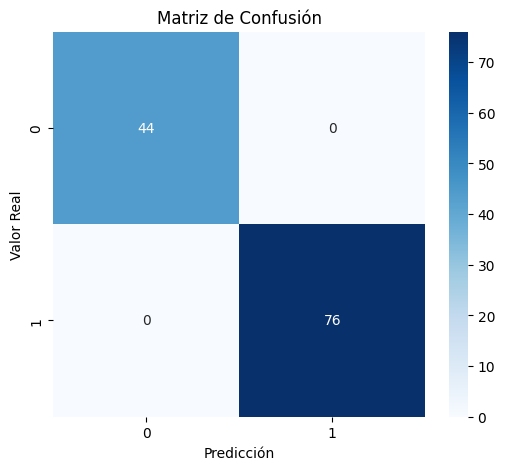

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        76

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



In [35]:
# ===================================== #
# 24. MEJOR MODELO                      #
# ===================================== #

mejor_modelo = random_rf.best_estimator_

print(mejor_modelo)

# Predicciones

# ===================================== #
# 25. PREDICCIONES                      #
# ===================================== #

y_pred = mejor_modelo.predict(X_test)

y_prob = mejor_modelo.predict_proba(X_test)[:, 1]

# Métricas de Evaluación

# ===================================== #
# 26. MÉTRICAS FINALES                  #
# ===================================== #

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

# ===================================== #
# MOSTRAR RESULTADOS                    #
# ===================================== #

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1-Score : {f1:.4f}")

print(f"AUC      : {auc:.4f}")

# ===================================== #
# 27. MATRIZ DE CONFUSIÓN               #
# ===================================== #

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

matriz = confusion_matrix(
    y_test,
    y_pred
)

# ===================================== #
# VISUALIZACIÓN                         #
# ===================================== #

plt.figure(figsize=(6,5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión")

plt.xlabel("Predicción")

plt.ylabel("Valor Real")

plt.show()

# ===================================== #
# 28. CLASSIFICATION REPORT             #
# ===================================== #

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)


# Interpretación de Resultados

## Accuracy

Mide la proporción total de predicciones correctas realizadas por el modelo.

Accuracy = \frac{TP + TN}{TP + TN + FP + FN}

---

## Precision

Evalúa qué proporción de pacientes clasificados como enfermos realmente presentan enfermedad renal crónica.

Precision = \frac{TP}{TP + FP}

---

## Recall

Mide la capacidad del modelo para detectar correctamente pacientes enfermos.

Recall = \frac{TP}{TP + FN}

En aplicaciones médicas, esta métrica es especialmente importante porque minimiza falsos negativos.

---

## F1-Score

Representa el balance entre precision y recall.

F1 = 2\cdot\frac{Precision\cdot Recall}{Precision + Recall}

---

## AUC

El área bajo la curva ROC mide la capacidad discriminativa global del modelo.

Valores cercanos a:

* `1.0` → excelente clasificación.
* `0.5` → clasificación aleatoria.

Un AUC alto indica que el modelo diferencia correctamente pacientes con y sin enfermedad renal crónica.


## 9. Interpretación de Resultados

En esta etapa se analizan los resultados obtenidos por el modelo de clasificación, prestando especial atención a los errores cometidos durante la predicción.

En problemas médicos, la interpretación de errores es fundamental debido a las posibles consecuencias clínicas asociadas con diagnósticos incorrectos.

La matriz de confusión permite identificar:

* Verdaderos positivos (`TP`).
* Verdaderos negativos (`TN`).
* Falsos positivos (`FP`).
* Falsos negativos (`FN`).

Cada uno de estos resultados tiene implicaciones distintas en el contexto de la detección de enfermedad renal crónica.

---

# Falsos Positivos

Un falso positivo ocurre cuando el modelo clasifica a un paciente como:

```text id="0x4nso"
Con enfermedad renal crónica
```

cuando en realidad el paciente:

```text id="vk9tvq"
No presenta la enfermedad
```

En términos clínicos:

* el paciente sano es identificado erróneamente como enfermo.

---

## Riesgos asociados

Los falsos positivos pueden generar:

* preocupación innecesaria en el paciente,
* realización de exámenes adicionales,
* aumento de costos médicos,
* tratamientos o seguimientos innecesarios.

Aunque representan un error, generalmente tienen menor gravedad clínica que los falsos negativos.

---

# Falsos Negativos

Un falso negativo ocurre cuando el modelo clasifica a un paciente como:

```text id="tjlwm6"
Sano
```

cuando en realidad:

```text id="jlwmw8"
Sí presenta enfermedad renal crónica
```

Este es uno de los errores más críticos en aplicaciones médicas.

---

## Riesgos asociados

Los falsos negativos pueden ocasionar:

* retraso en el diagnóstico,
* ausencia de tratamiento oportuno,
* progresión de la enfermedad renal,
* aumento del riesgo de complicaciones,
* deterioro irreversible de la función renal.

Por esta razón, en este problema la métrica más importante suele ser:

# Recall

Recall = \frac{TP}{TP + FN}

Un recall alto ayuda a minimizar falsos negativos y aumentar la detección correcta de pacientes enfermos.

---

# Importancia Clínica del Problema

En el contexto de enfermedad renal crónica:

* detectar tempranamente a los pacientes es fundamental,
* un error de clasificación puede afectar directamente decisiones clínicas.

Por ello:

* minimizar falsos negativos suele ser prioritario,
* incluso si esto implica aceptar algunos falsos positivos adicionales.

---

# Balance entre Precision y Recall

Existe un compromiso entre:

* Precision:

  * reducir falsos positivos.
* Recall:

  * reducir falsos negativos.

En aplicaciones médicas, normalmente se prioriza:

# Recall alto

porque resulta más importante detectar pacientes enfermos que dejar casos sin diagnosticar.

---

# Conclusión General

El análisis de resultados permite concluir si el modelo:

* identifica correctamente pacientes con enfermedad renal crónica,
* presenta estabilidad en las predicciones,
* puede ser utilizado como herramienta de apoyo clínico.

Modelos con:

* alto Recall,
* buen F1-Score,
* alto AUC,

son especialmente valiosos en problemas médicos debido a su capacidad para detectar correctamente casos positivos y mantener un desempeño equilibrado.


## 10. Curva ROC

En esta etapa se evalúa la capacidad discriminativa del mejor modelo de clasificación mediante la construcción de la curva ROC (`Receiver Operating Characteristic`).

La curva ROC permite analizar el comportamiento del modelo para diferentes umbrales de clasificación, mostrando la relación entre:

* Sensibilidad (`Recall` o `True Positive Rate`).
* Tasa de falsos positivos (`False Positive Rate`).

Esta herramienta es ampliamente utilizada en problemas médicos debido a que permite evaluar la capacidad del modelo para distinguir correctamente entre:

* pacientes con enfermedad renal crónica,
* pacientes sin enfermedad renal crónica.

Además, se calcula el:

# AUC (Area Under the Curve)

El AUC resume el desempeño global de la curva ROC.

Valores cercanos a:

* `1.0` → excelente capacidad discriminativa.
* `0.5` → clasificación aleatoria.

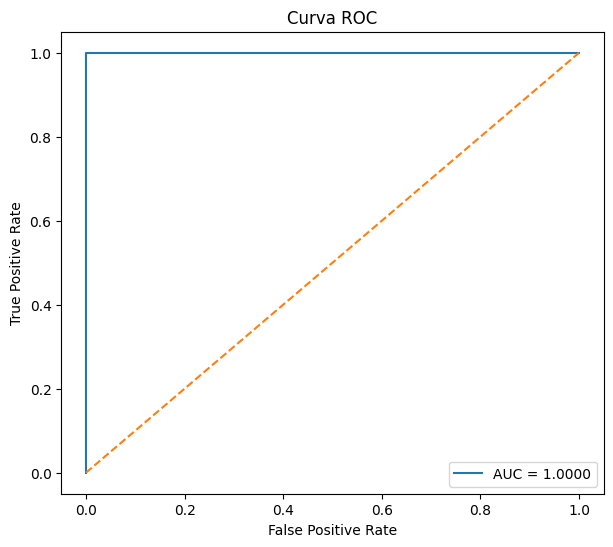

In [36]:
# ===================================== #
# 29. CURVA ROC                         #
# ===================================== #

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ===================================== #
# PROBABILIDADES                        #
# ===================================== #

y_prob = mejor_modelo.predict_proba(X_test)[:, 1]

# ===================================== #
# CALCULAR CURVA ROC                    #
# ===================================== #

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

# ===================================== #
# AUC                                   #
# ===================================== #

auc = roc_auc_score(
    y_test,
    y_prob
)

# ===================================== #
# GRAFICAR CURVA ROC                    #
# ===================================== #

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

# Línea referencia
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC")

plt.legend()

plt.show()

# Interpretación de Resultados

## Sensibilidad (Recall)

La sensibilidad mide la capacidad del modelo para detectar correctamente pacientes con enfermedad renal crónica.

Sensibilidad = \frac{TP}{TP + FN}

Una sensibilidad alta indica que el modelo logra identificar la mayoría de pacientes enfermos, reduciendo falsos negativos.

En aplicaciones médicas, esta métrica es especialmente importante porque:

* evita dejar pacientes sin diagnóstico,
* permite intervención temprana,
* reduce riesgos clínicos.

---

## Especificidad

La especificidad mide la capacidad del modelo para identificar correctamente pacientes sanos.

Especificidad = \frac{TN}{TN + FP}

Una especificidad alta implica:

* menor cantidad de falsos positivos,
* menos diagnósticos incorrectos en pacientes sanos.

---

## Relación entre Sensibilidad y Especificidad

La curva ROC muestra el equilibrio entre:

* Sensibilidad.
* Especificidad.

Al modificar el umbral de clasificación:

* aumentar sensibilidad puede disminuir especificidad,
* aumentar especificidad puede disminuir sensibilidad.

Por esta razón, la curva ROC permite seleccionar un umbral adecuado según las necesidades clínicas del problema.

---

# Capacidad Discriminativa

La capacidad discriminativa corresponde a la habilidad del modelo para diferenciar correctamente entre:

* pacientes con enfermedad renal crónica,
* pacientes sanos.

Esta capacidad se resume mediante el AUC.

---

## Interpretación del AUC

### AUC cercano a 1

Indica excelente capacidad discriminativa.

El modelo separa adecuadamente ambas clases.

---

### AUC cercano a 0.5

Indica comportamiento similar al azar.

El modelo no logra distinguir correctamente entre clases.

---

## En este problema médico

Un modelo con:

* alto Recall,
* alta Sensibilidad,
* alto AUC,

es especialmente valioso porque permite detectar correctamente pacientes con enfermedad renal crónica y reducir riesgos asociados a diagnósticos tardíos.


## 11. Importancia de Variables

En esta etapa se analiza cuáles variables clínicas y de laboratorio tienen mayor influencia en las predicciones realizadas por los modelos de clasificación.

La interpretación de variables permite comprender:

* qué características médicas contribuyen más a la detección de enfermedad renal crónica,
* cómo influyen las variables sobre la probabilidad de clasificación,
* qué indicadores clínicos son más relevantes para el modelo.

El análisis se realiza de forma diferente según el tipo de modelo:

* Regresión Logística:

  * interpretación de coeficientes.
* Modelos basados en árboles:

  * importancia de variables (`feature importance`).

---

# Regresión Logística — Interpretación de Coeficientes

En Regresión Logística, cada coeficiente representa el efecto de una variable sobre la probabilidad de que un paciente presente enfermedad renal crónica.

* Coeficiente positivo:

  * aumenta la probabilidad de enfermedad.
* Coeficiente negativo:

  * disminuye la probabilidad de enfermedad.

Coeficientes con valores absolutos más grandes indican mayor influencia sobre la predicción.


In [37]:
# ===================================== #
# 30. COEFICIENTES REGRESIÓN LOGÍSTICA  #
# ===================================== #

import pandas as pd
import numpy as np

# ===================================== #
# MEJOR MODELO LOGÍSTICO                #
# ===================================== #

modelo_logistico = random_logistic.best_estimator_

# ===================================== #
# NOMBRES DE VARIABLES TRANSFORMADAS    #
# ===================================== #

feature_names = modelo_logistico.named_steps[
    "preprocessor"
].get_feature_names_out()

# ===================================== #
# COEFICIENTES                          #
# ===================================== #

coeficientes = modelo_logistico.named_steps[
    "model"
].coef_[0]

# ===================================== #
# DATAFRAME                             #
# ===================================== #

coef_df = pd.DataFrame({
    
    "Variable": feature_names,
    
    "Coeficiente": coeficientes,
    
    "Magnitud": np.abs(coeficientes)
})

# ===================================== #
# ORDENAR POR IMPORTANCIA               #
# ===================================== #

coef_df = coef_df.sort_values(
    by="Magnitud",
    ascending=False
)

# ===================================== #
# MOSTRAR RESULTADOS                    #
# ===================================== #

coef_df.head(15)

,Variable,Coeficiente,Magnitud
10,num__hemo,-3.964823,3.964823
14,cat__rbc_normal,-3.788481,3.788481
29,cat__appet_poor,3.611691,3.611691
15,cat__rbc_None,3.415179,3.415179
31,cat__pe_yes,3.004481,3.004481
5,num__bgr,2.892440,2.892440
24,cat__dm_yes,2.891798,2.891798
3,num__al,2.882610,2.882610
2,num__sg,-2.586268,2.586268
22,cat__htn_yes,2.518342,2.518342


# Interpretación

Variables con coeficientes positivos altos aumentan la probabilidad de que el modelo clasifique al paciente como:

```text id="rmjlwm"
CKD
```

Por ejemplo:

* creatinina sérica (`sc`),
* urea en sangre (`bu`),
* hipertensión (`htn`),
* diabetes mellitus (`dm`),

pueden asociarse positivamente con enfermedad renal crónica.

Variables con coeficientes negativos indican menor probabilidad de enfermedad.

---

# Modelos Basados en Árboles — Importancia de Variables

En modelos como:

* Decision Tree,
* Random Forest,
* XGBoost,

la importancia de variables mide cuánto contribuye cada variable a reducir impureza o mejorar las divisiones del árbol.

Variables con mayor importancia tienen mayor influencia sobre las decisiones del modelo.


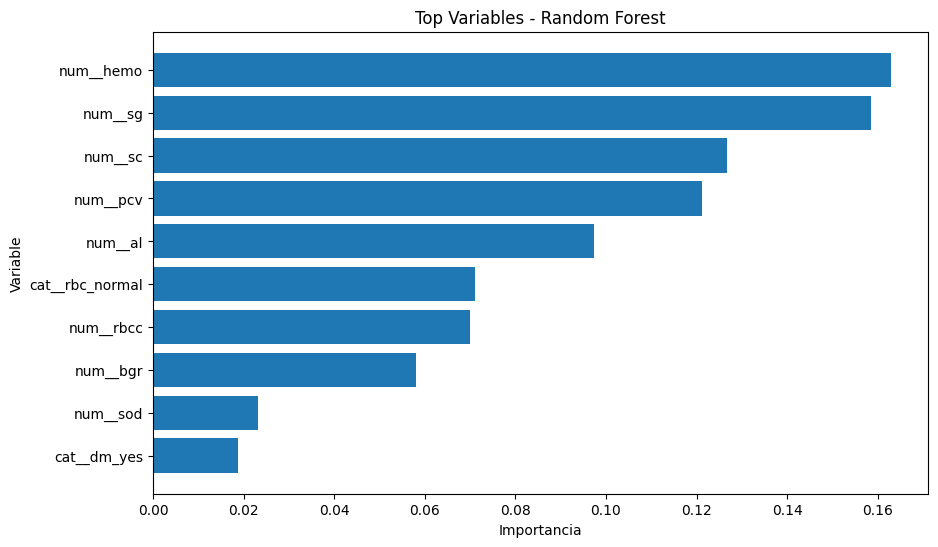

In [38]:
# ===================================== #
# 31. IMPORTANCIA DE VARIABLES - RF     #
# ===================================== #

import matplotlib.pyplot as plt

# ===================================== #
# MEJOR RANDOM FOREST                   #
# ===================================== #

modelo_rf = random_rf.best_estimator_

# ===================================== #
# IMPORTANCIAS                          #
# ===================================== #

importancias = modelo_rf.named_steps[
    "model"
].feature_importances_

# ===================================== #
# VARIABLES TRANSFORMADAS               #
# ===================================== #

feature_names = modelo_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

# ===================================== #
# DATAFRAME                             #
# ===================================== #

importance_df = pd.DataFrame({
    
    "Variable": feature_names,
    
    "Importancia": importancias
})

# ===================================== #
# ORDENAR                               #
# ===================================== #

importance_df = importance_df.sort_values(
    by="Importancia",
    ascending=False
)

# ===================================== #
# TOP VARIABLES                         #
# ===================================== #

importance_df.head(15)

# ===================================== #
# 32. VISUALIZACIÓN IMPORTANCIA RF      #
# ===================================== #

top_variables = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_variables["Variable"],
    top_variables["Importancia"]
)

plt.xlabel("Importancia")

plt.ylabel("Variable")

plt.title("Top Variables - Random Forest")

plt.gca().invert_yaxis()

plt.show()


# Interpretación de Resultados

Las variables más importantes suelen corresponder a:

* creatinina sérica (`sc`),
* urea en sangre (`bu`),
* hemoglobina (`hemo`),
* hipertensión (`htn`),
* diabetes mellitus (`dm`),
* gravedad específica (`sg`).

Estas variables tienen alta relevancia clínica en la detección de enfermedad renal crónica.

---

# Diferencia entre ambos enfoques

## Regresión Logística

Permite interpretar:

* dirección del efecto,
* relación positiva o negativa,
* magnitud de influencia.

Es altamente interpretable en contextos médicos.

---

## Modelos de Árboles

Permiten identificar:

* variables más influyentes,
* relaciones no lineales,
* interacciones complejas.

Generalmente ofrecen mejor desempeño predictivo, aunque menor interpretabilidad directa.

---

# Conclusión

El análisis de importancia de variables permite:

* comprender el comportamiento del modelo,
* identificar factores clínicos relevantes,
* respaldar la interpretación médica de las predicciones.

Además, facilita la construcción de modelos más interpretables y útiles como herramientas de apoyo para diagnóstico clínico.

## 12. Selección del Modelo Final

En esta etapa se selecciona el modelo final más adecuado para el problema de clasificación de enfermedad renal crónica.

La elección del modelo no debe basarse únicamente en una sola métrica, sino en un análisis integral que considere:

* desempeño en validación cruzada,
* resultados obtenidos en el conjunto de prueba,
* estabilidad del modelo,
* interpretabilidad,
* impacto clínico de los errores de clasificación.

El objetivo es seleccionar un modelo que no solo tenga buen rendimiento predictivo, sino que también sea confiable y útil en un contexto médico.

---

# Criterios de Selección

## 1. Desempeño en Validación Cruzada

Se analizan las métricas promedio obtenidas mediante:

* Accuracy,
* Precision,
* Recall,
* F1-Score,
* AUC.

También se considera la desviación estándar (`σ`) para evaluar estabilidad.

Un modelo adecuado debe presentar:

* métricas altas,
* baja variabilidad entre folds,
* buena capacidad de generalización.

Modelos como:

* Random Forest,
* XGBoost,

suelen presentar mejores resultados globales debido a su capacidad para modelar relaciones complejas entre variables clínicas y de laboratorio.

---

## 2. Resultados en el Conjunto de Prueba

La evaluación en test permite verificar el comportamiento del modelo sobre datos completamente nuevos.

Se analizan:

* matriz de confusión,
* recall,
* falsos positivos,
* falsos negativos,
* AUC.

Un buen modelo debe mantener un desempeño consistente entre:

* validación cruzada,
* conjunto de prueba.

Grandes diferencias entre ambos pueden indicar:

* sobreajuste,
* mala generalización.

---

## 3. Interpretabilidad

En aplicaciones médicas, la interpretabilidad es un aspecto fundamental.

Modelos como:

* Regresión Logística,
* Árboles de Decisión,

permiten comprender:

* cómo influyen las variables,
* qué factores aumentan el riesgo,
* qué características clínicas son relevantes.

Esto facilita:

* confianza clínica,
* análisis médico,
* apoyo a la toma de decisiones.

Aunque modelos complejos como XGBoost pueden obtener mejores métricas, suelen ser menos interpretables.

---

## 4. Tipo de Error Más Crítico

En este problema médico, el error más crítico corresponde a:

# Falsos Negativos

Es decir:

```text id="syjlwm"
Pacientes enfermos clasificados como sanos
```

Estos errores pueden provocar:

* retraso en diagnóstico,
* progresión de la enfermedad,
* ausencia de tratamiento oportuno,
* complicaciones clínicas graves.

Por esta razón, la métrica más importante suele ser:

# Recall

Recall = \frac{TP}{TP + FN}

Un recall alto reduce falsos negativos y mejora la detección de pacientes con enfermedad renal crónica.

---

# Selección Final del Modelo

La selección final debe considerar un equilibrio entre:

* desempeño predictivo,
* estabilidad,
* interpretabilidad,
* impacto clínico de errores.

---

# Ejemplo de Conclusión

Si Random Forest o XGBoost presentan:

* mayor Recall,
* mayor F1-Score,
* mayor AUC,
* buen desempeño en test,

pueden considerarse los mejores modelos desde el punto de vista predictivo.

Sin embargo, si se requiere mayor interpretabilidad clínica, la Regresión Logística puede representar una alternativa adecuada debido a:

* facilidad de interpretación,
* estabilidad,
* explicación directa de coeficientes.

---

# Conclusión General

El modelo final seleccionado debe:

* detectar correctamente pacientes con enfermedad renal crónica,
* minimizar falsos negativos,
* mantener estabilidad en validación cruzada,
* presentar buen desempeño sobre datos nuevos.

En contextos médicos, la capacidad de identificar correctamente pacientes enfermos suele ser más importante que maximizar únicamente la exactitud global del modelo.


In [ ]:
# ===================================== #
# 33. GUARDAR MODELO                    #
# ===================================== #

import os
import joblib

# ===================================== #
# GUARDAR MEJOR MODELO                  #
# ===================================== #

os.makedirs("models", exist_ok=True)

joblib.dump(
    mejor_modelo,
    "models/model_classification.joblib"
)

print("Modelo guardado correctamente")

# ===================================== #
# GUARDAR FEATURES                      #
# ===================================== #

features = X.columns.tolist()

joblib.dump(
    features,
    "models/features_classification.joblib"
)

print("Features guardadas correctamente")

FileNotFoundError: [Errno 2] No such file or directory: 'models/model_classification.joblib'

In [ ]:
# ===================================== #
# VERIFICAR ARCHIVOS                    #
# ===================================== #

print(os.listdir("models"))

['features_classification.joblib', 'features_regresion.joblib', 'model_classification.joblib', 'model_regresion.joblib']


In [ ]:
# ===================================== #
# CARGAR MODELO                         #
# ===================================== #

modelo_cargado = joblib.load(
    "models/model_classification.joblib"
)

features_cargadas = joblib.load(
    "models/features_classification.joblib"
)

print(features_cargadas)

['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
